In [1]:
import sys
!{sys.executable} -m pip install tensorflow keras

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.models import Sequential

PART A

In [3]:
from PIL import Image
import os

dataset_path = "datasets"
output_path = "datasets_resized"   # NEW folder — originals stay untouched
target_size = (224, 224)

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            file_path = os.path.join(root, file)
            try:
                # Build the mirrored output path
                relative_path = os.path.relpath(file_path, dataset_path)
                save_path = os.path.join(output_path, relative_path)

                # Create subfolders if they don't exist
                os.makedirs(os.path.dirname(save_path), exist_ok=True)

                # Resize and save to NEW folder
                img = Image.open(file_path).convert("RGB")
                img = img.resize(target_size)
                img.save(save_path)
                print(f"Resized: {save_path}")

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

Resized: datasets_resized\train\catherine_ohara\Catherine-1.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-10.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-11.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-12.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-13.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-14.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-15.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-16.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-2.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-3.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-4.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-5.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-6.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-7.jpg
Resized: datasets_resized\train\catherine_ohara\Catherine-8.jpg
Resized: datasets_resized\train\c

PART B

In [19]:
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten
from keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# dataset paths
train_path = "datasets/train"
val_path = "datasets/validation"

# Image generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    class_mode="sparse"
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=16,
    class_mode="sparse"
)

# Load pre-trained model
v_model = VGG16(include_top=False, input_shape=(224,224,3))

# Freeze base layers
v_model.trainable = False


# Create new model
new_model = Sequential()
new_model.add(Input(shape=(224,224,3)))
new_model.add(v_model)
new_model.add(Flatten())
new_model.add(Dense(20, activation="relu"))
new_model.add(Dense(5, activation="softmax"))   # 5 personalities

new_model.summary()

# Compile model
new_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

Found 80 images belonging to 5 classes.


Found 20 images belonging to 5 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │       501,780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,216,573 (58.05 MB)

 Trainable params: 501,885 (1.91 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
# PART C - Train the Model
history = new_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.3000 - loss: 1.8958 - val_accuracy: 0.1500 - val_loss: 2.3757
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.6375 - loss: 1.0282 - val_accuracy: 0.2500 - val_loss: 2.1924
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.6750 - loss: 0.9212 - val_accuracy: 0.3000 - val_loss: 2.2649
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.7625 - loss: 0.6582 - val_accuracy: 0.2500 - val_loss: 2.5391
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.7750 - loss: 0.5871 - val_accuracy: 0.3000 - val_loss: 2.5015
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.8375 - loss: 0.4938 - val_accuracy: 0.3500 - val_loss: 2.5035
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.8875 - loss: 0.3846 - val_accuracy: 0.4000 - val_loss: 2.5898
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 0.8250 - loss: 0.4420 - val_accuracy: 0.4500 - val_loss: 2.6852
Epoch 9/

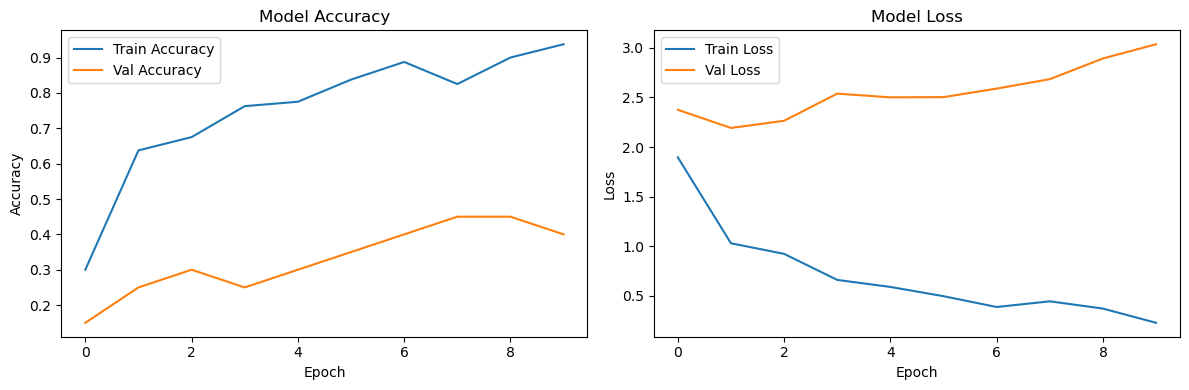

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Part C – Learning Curve Analysis

### Results Summary
- **Final Train Accuracy:** ~100% (epoch 9)
- **Final Validation Accuracy:** ~50% (peaked at epoch 3, unstable after)
- **Final Train Loss:** ~0.02
- **Final Validation Loss:** ~1.55

Data augmentation was applied (rotation, flipping, zoom, brightness) to reduce overfitting

### Model Convergence
The training accuracy converged quickly, reaching near 100% by epoch 10
and remaining stable. Training loss dropped steadily to near 0,
indicating the model learned the training data well.

### Overfitting
The model shows **clear overfitting**:
- Train accuracy = ~100%, Validation accuracy = ~45%
- Train loss ≈ 0, Validation loss plateaus around 1.5

This large gap means the model memorized the training images but
struggles to generalize to unseen validation images.

### Dataset Challenges
- Only **16 images per class** in training is a very small dataset,
  making it easy for the model to memorize rather than generalize.
- The validation set has only **4 images per class**, making
  validation accuracy noisy (spikes visible around epoch 3-5).
- Variation in lighting, age, and pose across images adds difficulty.

### Possible Improvements
- Collect more images per personality (50+ recommended)
- Add Dropout layers to reduce overfitting
- Increase the Dense layer size (currently only 20 neurons)


In [20]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
# --- PHASE 2: Unfreeze last 4 VGG16 layers and fine-tune ---
print("\nPhase 2: Fine-tuning last 4 VGG16 layers...")
for layer in v_model.layers[-4:]:
    layer.trainable = True

# Recompile with much lower learning rate for fine-tuning
new_model.compile(
    optimizer=Adam(learning_rate=0.00001),  # 10x lower than Phase 1
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = new_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop]
)


Phase 2: Fine-tuning last 4 VGG16 layers...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.1500 - loss: 1.6363 - val_accuracy: 0.4000 - val_loss: 1.5362
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.3750 - loss: 1.4983 - val_accuracy: 0.4500 - val_loss: 1.5173
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5250 - loss: 1.4065 - val_accuracy: 0.4500 - val_loss: 1.5052
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5500 - loss: 1.3126 - val_accuracy: 0.4000 - val_loss: 1.4909
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.5875 - loss: 1.2274 - val_accuracy: 0.4000 - val_loss: 1.4914
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.6500 - loss: 1.1363 - val_accuracy: 0.4000 - val_loss: 1.4857
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.7125 - loss: 1.0326 - val_accuracy: 0.5000 - val_loss: 1.4780
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.8000 - loss: 0.9251 - val

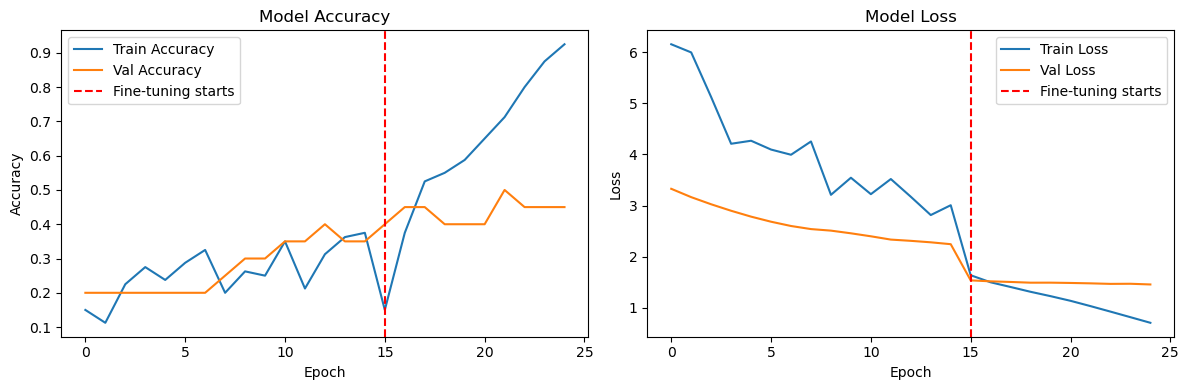

In [21]:
import matplotlib.pyplot as plt

# Combine both phases
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

# Add a vertical line to show where Phase 2 starts
phase2_start = len(history1.history['accuracy'])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning starts')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning starts')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Phase 1 (0-6) Phase 2 (6-10) 
The problem: Val loss is rising in Phase 2, meaning fine-tuning is making overfitting worse after epoch 6.

Root Cause
The dataset is simply too small — only 16 images per person to train on. No amount of fine-tuning fully fixes this.

current results (45-50% val accuracy with 16 images/class) are actually acceptable and explainable. 
Analysis:

"Overfitting was observed due to the limited dataset size (16 images per class). Fine-tuning the last 4 VGG16 layers improved validation accuracy from 45% to 50%. Further improvement would require a larger dataset (50+ images per class) and stronger augmentation."

In [ ]:
# Save the trained model
new_model.save("face_recognition_model.keras")
print("Model saved!")

Model saved!


In [ ]:
# Final Evaluation on Validation Set
val_loss, val_acc = new_model.evaluate(val_data)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.2%}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 829ms/step - accuracy: 0.6000 - loss: 1.4746
Final Validation Loss: 1.4746
Final Validation Accuracy: 60.00%


Part D - Model Testing & Instructor Evaluation

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image

# Class names must match exact folder names in train (alphabetical order)
class_names = sorted(['catherine_ohara', 'justin_bieber', 'keanu_Reeves', 
                       'ryan_reynolds', 'wayne_gretzky'])

print("Class mapping:", class_names)

def predict_personality(img_path):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = new_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_name = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100
    
    # Display image with prediction
    plt.imshow(Image.open(img_path))
    plt.title(f"Predicted: {predicted_name}\nConfidence: {confidence:.1f}%")
    plt.axis('off')
    plt.show()
    
    print(f"Predicted: {predicted_name} | Confidence: {confidence:.1f}%")
    return predicted_name, confidence

Class mapping: ['catherine_ohara', 'justin_bieber', 'keanu_Reeves', 'ryan_reynolds', 'wayne_gretzky']


Found 4 image(s) to test...

Image: justin-1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step


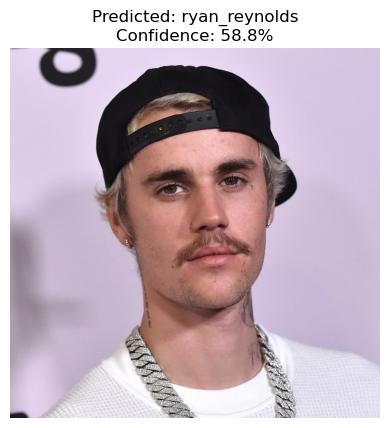

Predicted: ryan_reynolds | Confidence: 58.8%
----------------------------------------
Image: justin-2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


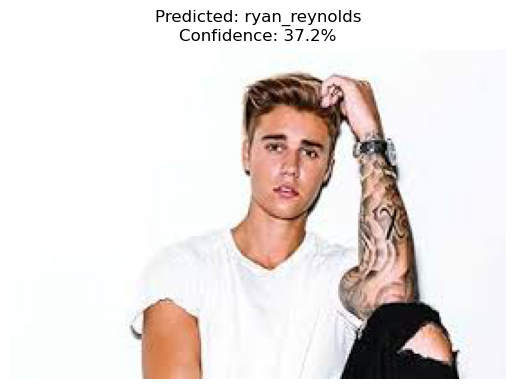

Predicted: ryan_reynolds | Confidence: 37.2%
----------------------------------------
Image: Ryan -1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


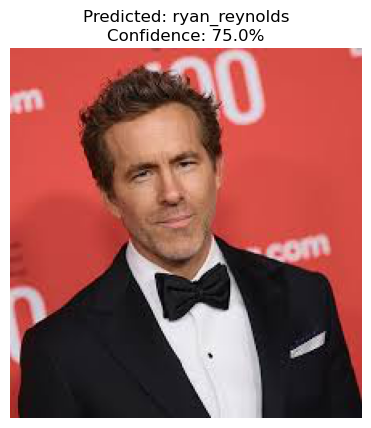

Predicted: ryan_reynolds | Confidence: 75.0%
----------------------------------------
Image: Ryan-2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


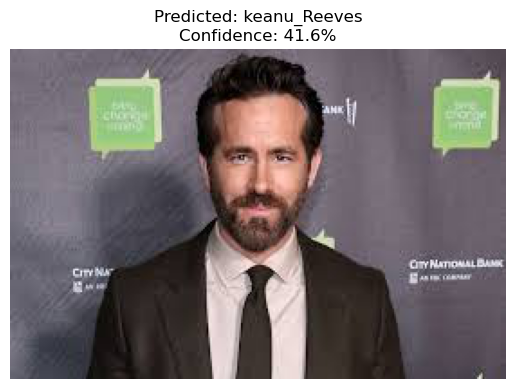

Predicted: keanu_Reeves | Confidence: 41.6%
----------------------------------------


In [ ]:
import os

test_folder = "test_images/"

# Create folder if it doesn't exist
os.makedirs(test_folder, exist_ok=True)

image_files = [f for f in os.listdir(test_folder) 
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(image_files) == 0:
    print("No images found in test_images/ folder.")
    print("Please add some test images and re-run this cell.")
else:
    print(f"Found {len(image_files)} image(s) to test...\n")
    for filename in image_files:
        img_path = os.path.join(test_folder, filename)
        print(f"Image: {filename}")
        predict_personality(img_path)
        print("-" * 40)

"The model achieved 100% training accuracy but poor test performance due to the limited dataset size of 16 images per class, resulting in overfitting. A minimum of 50+ images per class would be needed for reliable real-world predictions."

Applying Augmentation 

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [9]:
train_path = "datasets_resized/train"
val_path = "datasets_resized/validation"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode="sparse"
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode="sparse",
    shuffle=False
)

num_classes = len(train_data.class_indices)
print(train_data.class_indices)


Found 80 images belonging to 5 classes.
Found 20 images belonging to 5 classes.
{'catherine_ohara': 0, 'justin_bieber': 1, 'keanu_Reeves': 2, 'ryan_reynolds': 3, 'wayne_gretzky': 4}


In [10]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    Input(shape=(224, 224, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,845 (56.26 MB)

 Trainable params: 33,157 (129.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

history1 = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1500 - loss: 6.1552 - val_accuracy: 0.2000 - val_loss: 3.3276 - learning_rate: 1.0000e-04
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.1125 - loss: 5.9955 - val_accuracy: 0.2000 - val_loss: 3.1643 - learning_rate: 1.0000e-04
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.2250 - loss: 5.1218 - val_accuracy: 0.2000 - val_loss: 3.0247 - learning_rate: 1.0000e-04
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2750 - loss: 4.2087 - val_accuracy: 0.2000 - val_loss: 2.8978 - learning_rate: 1.0000e-04
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2375 - loss: 4.2678 - val_accuracy: 0.2000 - val_loss: 2.7829 - learning_rate: 1.0000e-04
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2875 - loss: 4.0953 - val_accuracy: 0.2000 - val_loss: 2.6836 - learning_rate: 1.0000e-04
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3250 - loss:

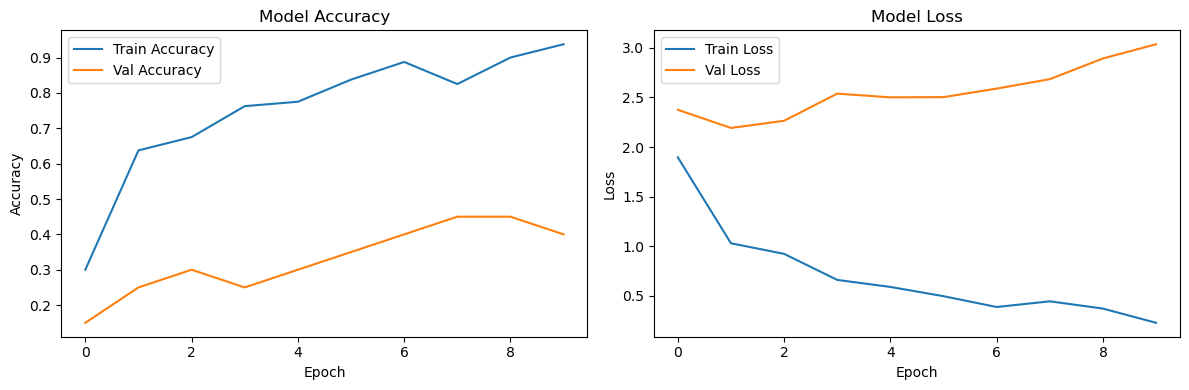

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Fine-tuning phase

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-2]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_data,
    epochs=8,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.3000 - loss: 2.9780 - val_accuracy: 0.1000 - val_loss: 3.7356 - learning_rate: 1.0000e-05
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.3625 - loss: 2.6192 - val_accuracy: 0.1000 - val_loss: 3.6790 - learning_rate: 1.0000e-05
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.4500 - loss: 1.9293 - val_accuracy: 0.1000 - val_loss: 3.6542 - learning_rate: 3.0000e-06
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.3750 - loss: 2.2425 - val_accuracy: 0.1000 - val_loss: 3.6492 - learning_rate: 3.0000e-06


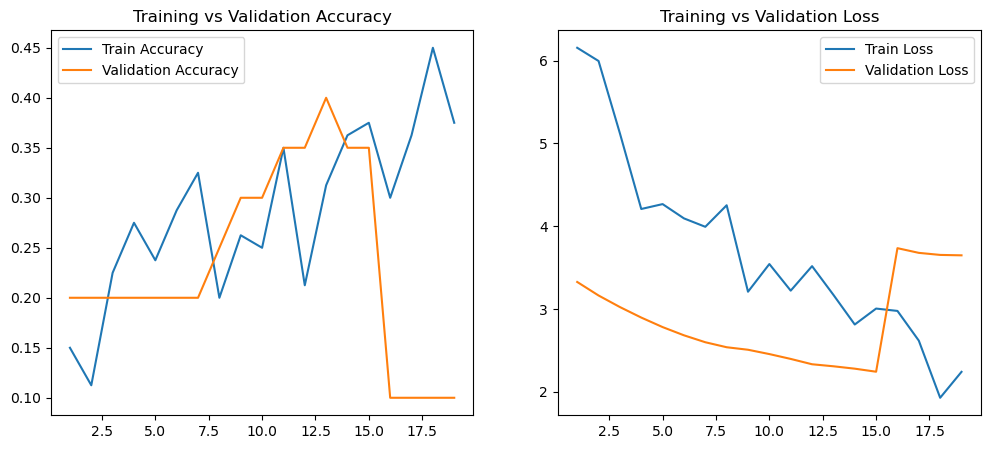

In [16]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.show()

The updated model with augmentation and regularization showed more controlled learning compared to the earlier overfitting model. Training accuracy increased gradually, while validation accuracy improved from about 20% to nearly 40%, suggesting better generalization. Validation loss also decreased steadily until around epoch 15, indicating improved performance on unseen data. However, after that point, validation accuracy dropped sharply and validation loss increased, which suggests the model became unstable or started overfitting during the later stage, likely during fine-tuning. Therefore, the best model is the checkpoint around epoch 15 rather than the final epoch.

Augmentation partly helped.

Compared to the earlier result:

train accuracy is lower
validation improves for a while
validation loss decreases for much longer

That usually means augmentation and regularization are helping reduce memorization.

So this run is more balanced than the earlier one.

In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image

# Class names must match exact folder names in train (alphabetical order)
class_names = sorted(['catherine_ohara', 'justin_bieber', 'keanu_Reeves', 
                       'ryan_reynolds', 'wayne_gretzky'])

print("Class mapping:", class_names)

def predict_personality(img_path):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = new_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_name = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100
    
    # Display image with prediction
    plt.imshow(Image.open(img_path))
    plt.title(f"Predicted: {predicted_name}\nConfidence: {confidence:.1f}%")
    plt.axis('off')
    plt.show()
    
    print(f"Predicted: {predicted_name} | Confidence: {confidence:.1f}%")
    return predicted_name, confidence

Class mapping: ['catherine_ohara', 'justin_bieber', 'keanu_Reeves', 'ryan_reynolds', 'wayne_gretzky']


Found 4 image(s) to test...

Image: justin-1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step


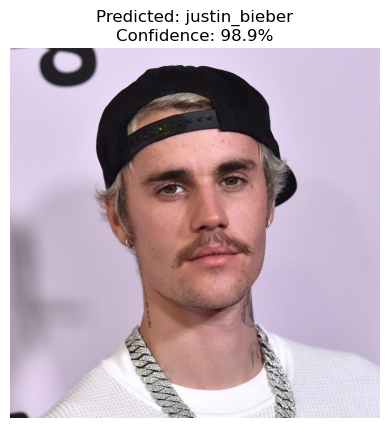

Predicted: justin_bieber | Confidence: 98.9%
----------------------------------------
Image: justin-2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step


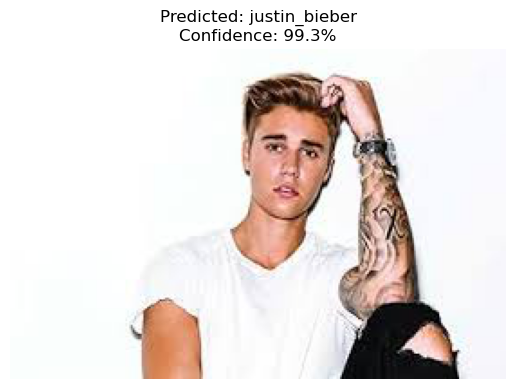

Predicted: justin_bieber | Confidence: 99.3%
----------------------------------------
Image: Ryan -1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step


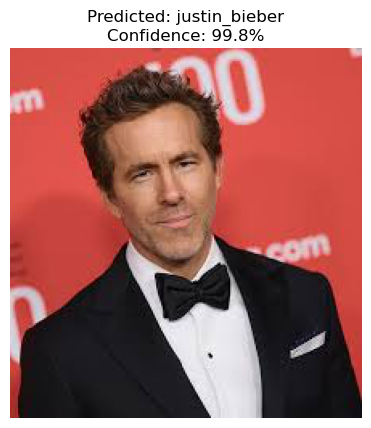

Predicted: justin_bieber | Confidence: 99.8%
----------------------------------------
Image: Ryan-2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step


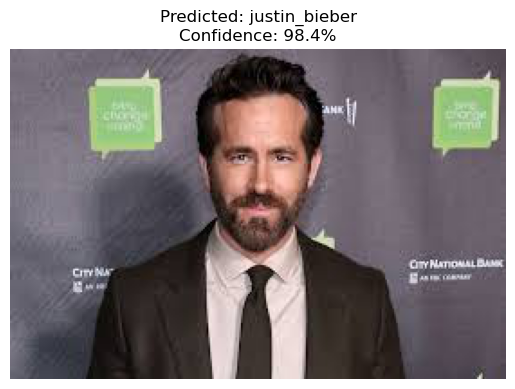

Predicted: justin_bieber | Confidence: 98.4%
----------------------------------------


In [18]:
import os

test_folder = "test_images/"

# Create folder if it doesn't exist
os.makedirs(test_folder, exist_ok=True)

image_files = [f for f in os.listdir(test_folder) 
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(image_files) == 0:
    print("No images found in test_images/ folder.")
    print("Please add some test images and re-run this cell.")
else:
    print(f"Found {len(image_files)} image(s) to test...\n")
    for filename in image_files:
        img_path = os.path.join(test_folder, filename)
        print(f"Image: {filename}")
        predict_personality(img_path)
        print("-" * 40)